In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torchvision import transforms, datasets, models
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

Data Augmentation

In [2]:
def get_augmentations():
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


Pre-Trainned model with Fine Tuning

In [3]:
class TransferLearningModel(nn.Module):
    def __init__(self):
        super(TransferLearningModel, self).__init__()
        self.model = models.resnet18(pretrained=True)
        # Freeze initial layers
        for param in self.model.parameters():
            param.requires_grad = False
        # Fine-tune the last two layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Linear(self.model.fc.in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.model(x))

Load and Split data

In [4]:
def load_and_split_data(healthy_folder, mdd_folder, batch_size=16):
    transform = get_augmentations()
    dataset = datasets.ImageFolder(root=os.path.dirname(healthy_folder), transform=transform)

    # Use 80% for training and 20% for validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=4, pin_memory=True)

    return train_loader, val_loader

Train and Evaluate

In [5]:
def train_and_evaluate(model, train_loader, val_loader, num_epochs=100):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Weighted loss for class imbalance (if any)
    pos_weight = torch.tensor([2.0]).to(device)  # Adjust based on dataset
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Advanced optimizer
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_acc = 0.0

    # Lists to store loss and accuracy values for plotting
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training loop
        model.train()
        total_train_loss = 0
        correct_train = 0
        total_samples_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct_train += (predicted == labels).sum().item()
            total_samples_train += labels.size(0)

        train_accuracy = correct_train / total_samples_train * 100
        train_losses.append(total_train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Validation loop
        model.eval()
        total_val_loss = 0
        correct_val = 0
        total_samples_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

                outputs = model(inputs)

                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

                predicted = (outputs > 0.5).float()
                correct_val += (predicted == labels).sum().item()
                total_samples_val += labels.size(0)

        val_accuracy = correct_val / total_samples_val * 100
        val_losses.append(total_val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)

        scheduler.step()

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.2f}%, ' +
              f'Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracy:.2f}%')

    print(f'Training complete. Best Validation Accuracy: {best_acc:.2f}%')

    # Plot training and validation curves
    plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

    # Evaluate the model on the validation set
    evaluate_model(model, val_loader, device)

Evaluate model

In [6]:

def evaluate_model(model, val_loader, device):
    """
    Evaluate the model on the validation set and generate evaluation metrics.
    """
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()  # Convert probabilities to binary predictions
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print evaluation metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'MDD'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

Plotting

In [7]:

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, val_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'MDD'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

Main Function

Epoch 1/100, Train Loss: 0.9475, Train Acc: 58.43%, Val Loss: 0.9085, Val Acc: 69.57%
Epoch 2/100, Train Loss: 0.9202, Train Acc: 61.80%, Val Loss: 0.8765, Val Acc: 69.57%
Epoch 3/100, Train Loss: 0.9095, Train Acc: 61.80%, Val Loss: 0.8668, Val Acc: 69.57%
Epoch 4/100, Train Loss: 0.8920, Train Acc: 64.04%, Val Loss: 0.8402, Val Acc: 69.57%
Epoch 5/100, Train Loss: 0.8681, Train Acc: 76.40%, Val Loss: 0.8219, Val Acc: 82.61%
Epoch 6/100, Train Loss: 0.8304, Train Acc: 82.02%, Val Loss: 0.7418, Val Acc: 91.30%
Epoch 7/100, Train Loss: 0.8009, Train Acc: 85.39%, Val Loss: 0.7716, Val Acc: 82.61%
Epoch 8/100, Train Loss: 0.8257, Train Acc: 78.65%, Val Loss: 0.7372, Val Acc: 86.96%
Epoch 9/100, Train Loss: 0.7903, Train Acc: 86.52%, Val Loss: 0.7251, Val Acc: 91.30%
Epoch 10/100, Train Loss: 0.7951, Train Acc: 83.15%, Val Loss: 0.7107, Val Acc: 86.96%
Epoch 11/100, Train Loss: 0.7772, Train Acc: 85.39%, Val Loss: 0.7925, Val Acc: 82.61%
Epoch 12/100, Train Loss: 0.7456, Train Acc: 87.64%,

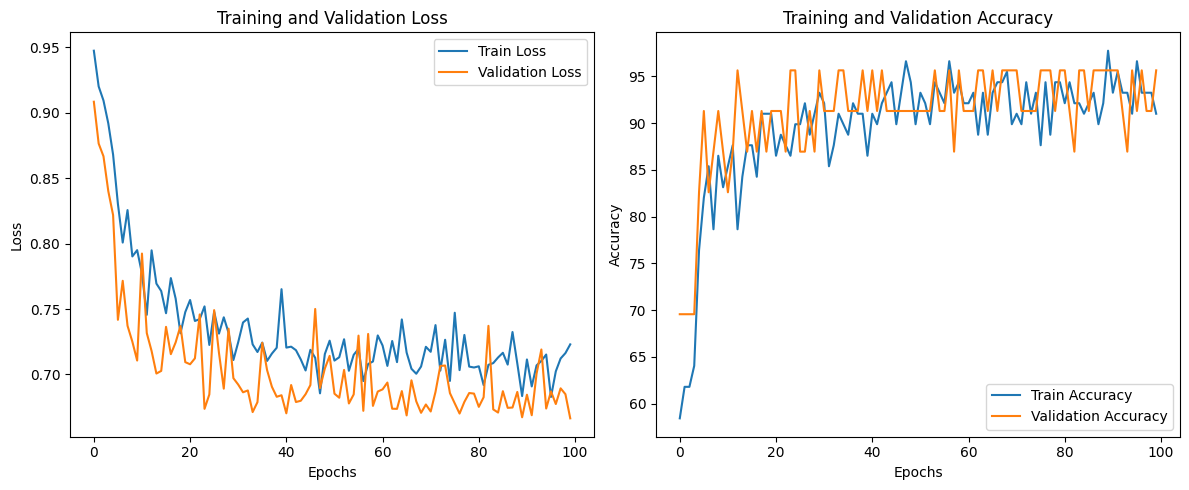

Accuracy: 0.9565
Precision: 0.9412
Recall: 1.0000
F1-Score: 0.9697


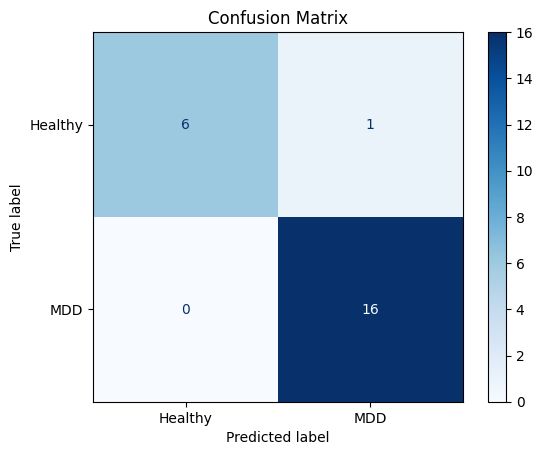

In [ ]:
if __name__ == "__main__":
    healthy_folder = "D:\Contourlet-CNN\Code\Superlet_image\Copy\Healthy"
    mdd_folder = "D:\Contourlet-CNN\Code\Superlet_image\Copy\MDD"

    train_loader, val_loader = load_and_split_data(healthy_folder, mdd_folder)
    
    model = TransferLearningModel()

  
    train_and_evaluate(model, train_loader, val_loader)